<h1>Train — ResNet-18 (baseline)</h1>

Trains and evaluates the ResNet-18 baseline classifier, then saves its results (`results_resnet18.pkl`) and weights (`{COMPONENT}_resnet18_cnn.pt`) to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 828 | Val: 203 | Test: 1476


## Define the model (Transfer Learning with ResNet-18)

In [2]:
model_resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, num_classes)  # no hidden layers — this one predates the tuning sweep

model_resnet18 = model_resnet18.to(device)

# ---------------------------------------------------------
# Loss and optimizer, with class weights for the imbalanced classes
# ---------------------------------------------------------
class_weights = make_class_weights(train_ds)
print("Applying class weights to loss function:")
for name, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {name:<15s}: {w:.3f}")

criterion_resnet18 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet18 = optim.Adam(model_resnet18.parameters(), lr=5e-4, weight_decay=WEIGHT_DECAY)

# mode='min' because we want to minimize loss; factor=0.5 halves the LR when
# triggered; patience=3 waits 3 epochs with no improvement before reducing it
scheduler_resnet18 = ReduceLROnPlateau(optimizer_resnet18, mode='min', factor=0.5, patience=3)

Applying class weights to loss function:
  Dysfunctional  : 0.558
  Empty          : 2.970
  Functional     : 0.293
  Scum           : 0.178


## Train, then plot training curves

[ResNet-18] Epoch   1/100 | LR: 5.00e-04 | train loss 0.9857 acc 0.582 | val loss 0.7662 acc 0.759 *


[ResNet-18] Epoch   2/100 | LR: 5.00e-04 | train loss 0.5248 acc 0.732 | val loss 0.6792 acc 0.660 *


[ResNet-18] Epoch   3/100 | LR: 5.00e-04 | train loss 0.2858 acc 0.845 | val loss 0.5084 acc 0.773 *


[ResNet-18] Epoch   4/100 | LR: 5.00e-04 | train loss 0.1895 acc 0.899 | val loss 0.4670 acc 0.828 *


[ResNet-18] Epoch   5/100 | LR: 5.00e-04 | train loss 0.2714 acc 0.891 | val loss 1.4795 acc 0.616


...

[ResNet-18] Epoch  14/100 | LR: 2.50e-04 | train loss 0.0175 acc 0.994 | val loss 0.5999 acc 0.842


[ResNet-18] Epoch  15/100 | LR: 2.50e-04 | train loss 0.0065 acc 1.000 | val loss 0.6558 acc 0.847


[ResNet-18] Epoch  16/100 | LR: 1.25e-04 | train loss 0.0067 acc 0.999 | val loss 0.6877 acc 0.842


[ResNet-18] Epoch  17/100 | LR: 1.25e-04 | train loss 0.0032 acc 1.000 | val loss 0.6830 acc 0.847


[ResNet-18] Epoch  18/100 | LR: 1.25e-04 | train loss 0.0054 acc 1.000 | val loss 0.6460 acc 0.852

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 18.

[ResNet-18] Restored best checkpoint (val loss = 0.4510)


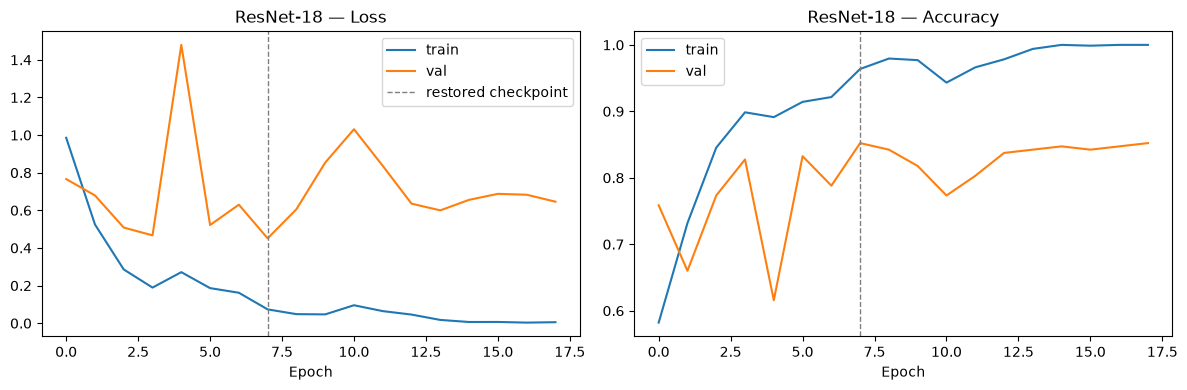

In [3]:
history_resnet18 = train_model(
    model_resnet18, train_loader, val_loader, optimizer_resnet18, scheduler_resnet18,
    criterion_resnet18, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18",
)
plot_training_curves(history_resnet18, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.566


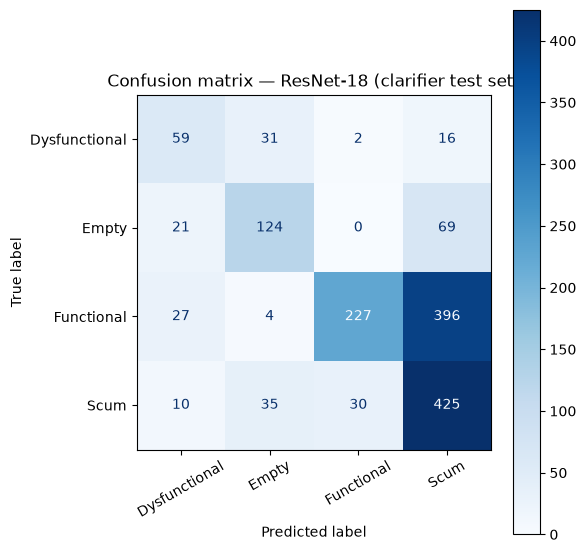

               precision    recall  f1-score   support

Dysfunctional      0.504     0.546     0.524       108
        Empty      0.639     0.579     0.608       214
   Functional      0.876     0.347     0.497       654
         Scum      0.469     0.850     0.605       500

     accuracy                          0.566      1476
    macro avg      0.622     0.581     0.559      1476
 weighted avg      0.677     0.566     0.552      1476



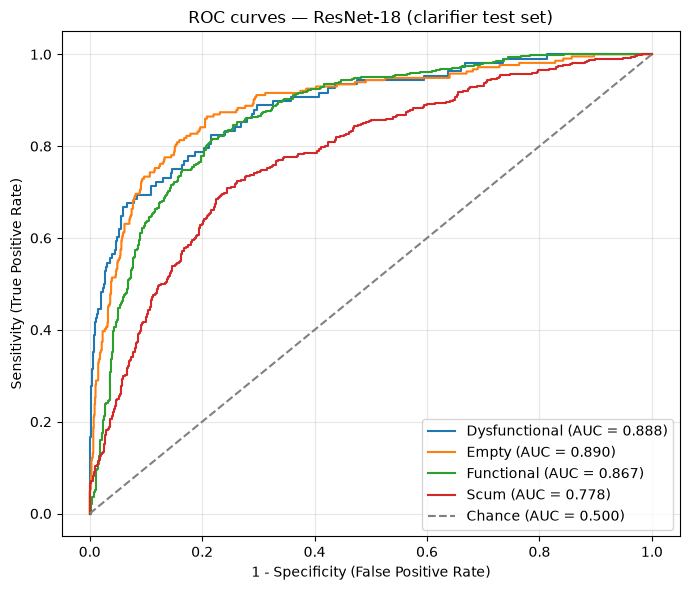

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.888
  Empty          : 0.890
  Functional     : 0.867
  Scum           : 0.778

Mean AUC (over 4/4 classes with test examples): 0.856


(np.float64(0.5657181571815718),
 {'Dysfunctional': 0.8880969785575048,
  'Empty': 0.8898555178695737,
  'Functional': 0.8670729257349494,
  'Scum': 0.7778032786885246})

In [4]:
evaluate_and_record(
    model_resnet18, test_loader, "ResNet-18", history_resnet18,
    img_size=IMG_TARGET_SIZE, hidden_layers=0, neurons=None,
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [5]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/results_clarifier_resnet18_CapeFlats.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
